In [22]:
import mdptoolbox
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd

In [23]:
P_0_matrix=np.array([[0.005,0.793,0.202],
                   [0.027,0.558,0.415],
                   [0.736,0.249,0.015]])

In [24]:
P_1_matrix=np.array([[0.718,0.254,0.028],
                   [0.347,0.097,0.556],
                   [0.015,0.956,0.029]])

In [25]:
T=[P_0_matrix,P_1_matrix]
reward_matrix=np.array([[0,0.699],[0,0.362],[0,0.715]])

print(reward_matrix.shape)
fh = mdptoolbox.mdp.FiniteHorizon(T, reward_matrix, 1, N=100000)
fh.run()

(3, 2)


In [26]:
print(fh.policy[0])

[1 1 1 ... 1 1 1]


In [27]:
fh.V

array([[5.85051678e+04, 5.85045828e+04, 5.85039977e+04, ...,
        1.31285000e+00, 6.99000000e-01, 0.00000000e+00],
       [5.85047498e+04, 5.85041648e+04, 5.85035797e+04, ...,
        1.03720700e+00, 3.62000000e-01, 0.00000000e+00],
       [5.85048901e+04, 5.85043051e+04, 5.85037200e+04, ...,
        1.09229200e+00, 7.15000000e-01, 0.00000000e+00]])

In [28]:
def step(state,state_space,action,P_0_matrix,P_1_matrix,reward_matrix):
  new_state=state
  if(action==1):
    new_state=np.random.choice(state_space,replace=True,p=P_1_matrix[state])
    reward=reward_matrix[state][1]
  else:
    new_state=np.random.choice(state_space,replace=True,p=P_0_matrix[state])
    reward=reward_matrix[state][0]
  return [new_state,reward]

In [29]:
state=0
rewards=[]
action_space=[0,1]
state_space=[0,1,2]
for i in range(100000):
    action=fh.policy[0][i]
    new_state,reward=step(state,state_space,action,P_0_matrix,P_1_matrix,reward_matrix)
    rewards.append(reward)
    state=new_state

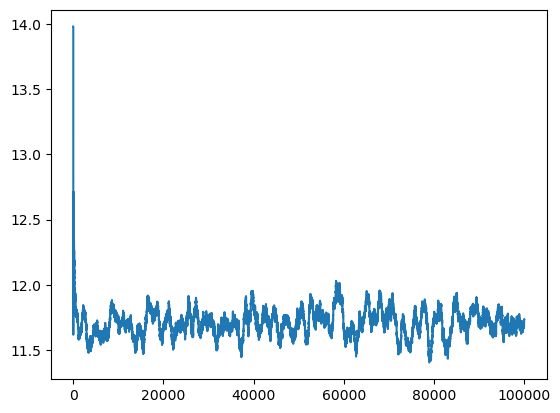

In [30]:
df=pd.DataFrame()
df['rewards']=[x*20 for x in rewards]
plt.plot(df['rewards'][:100000].rolling(1000,min_periods=1).mean())

